# Notebook 05 — Benchmark Analysis

Classical reference ladder (HF/MP2/CISD/CCSD/CCSD(T)/FCI) for ethylene and acetylene at STO-3G, compared to STO-3G VQE-UCCSD.

In [1]:
# ── Install dependencies (run once in clean Colab environment) ──
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "pyscf>=2.3", "qiskit>=1.0", "qiskit-aer>=0.14",
    "qiskit-nature>=0.7", "openfermion>=1.6",
    "scipy>=1.11", "matplotlib>=3.7", "pandas>=2.0",
    "h5py>=3.9", "tabulate>=0.9"])
print("✅ All dependencies installed")

✅ All dependencies installed



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, sys
os.environ['PYSCF_MAX_MEMORY'] = '4000'
if not os.path.exists('/content/quantum-alkene-alkyne-pyscf'):
    os.system('git clone https://github.com/Tommaso-R-Marena/quantum-alkene-alkyne-pyscf /content/quantum-alkene-alkyne-pyscf')
os.chdir('/content/quantum-alkene-alkyne-pyscf')
sys.path.insert(0, '/content/quantum-alkene-alkyne-pyscf')
os.makedirs('results', exist_ok=True)
print("✅ Repo loaded, results/ directory ready")

✅ Repo loaded, results/ directory ready


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, datetime, time
import qiskit, pyscf
print(f"qiskit {qiskit.__version__} | pyscf {pyscf.__version__}")

qiskit 2.4.1 | pyscf 2.13.0


## Step 1 — Run PySCF references for both molecules

In [4]:
import warnings; warnings.filterwarnings("ignore")
from src.molecule_builder import run_pyscf_references
from src.hamiltonian_utils import build_qiskit_nature_hamiltonian, exact_active_space_energy
from src.vqe_runner import run_uccsd_vqe_qiskit
from src.analysis import HA_TO_KCAL_MOL, CHEM_ACCURACY_mHa

MOLECULES = ["ethylene", "acetylene"]
BASIS = "sto-3g"
METHODS = ("HF", "MP2", "CISD", "CCSD", "CCSD(T)", "FCI")

classical = {}
for m in MOLECULES:
    print(f"--- {m} / {BASIS} ---")
    classical[m] = run_pyscf_references(m, basis=BASIS, methods=METHODS)
    for k, v in classical[m].items():
        print(f"  {k:8s} = {v:.8f} Ha")


--- ethylene / sto-3g ---


  HF       = -77.07212303 Ha
  MP2      = -77.19571049 Ha
  CISD     = -77.22286382 Ha
  CCSD     = -77.23416595 Ha
  CCSD(T)  = -77.23483513 Ha
  FCI      = -77.23539537 Ha
--- acetylene / sto-3g ---


  HF       = -75.85285077 Ha
  MP2      = -76.00344604 Ha
  CISD     = -76.00946443 Ha
  CCSD     = -76.02223418 Ha
  CCSD(T)  = -76.02287790 Ha
  FCI      = -76.02474481 Ha


## Step 2 — VQE-UCCSD (2e,2o) inline for both

In [5]:
vqe_results = {}
for m in MOLECULES:
    qop, prob = build_qiskit_nature_hamiltonian(m, basis=BASIS,
        active_electrons=2, active_orbitals=2)
    res = run_uccsd_vqe_qiskit(qop, prob, verbose=False)
    e_fci_as = exact_active_space_energy(qop, prob)
    vqe_results[m] = {
        "vqe_energy": float(res["final_energy_Ha"]),
        "fci_as":     float(e_fci_as),
    }
    print(f"{m}: VQE = {res['final_energy_Ha']:.8f} Ha,  FCI(AS) = {e_fci_as:.8f} Ha")


ethylene: VQE = -77.11662916 Ha,  FCI(AS) = -77.11662916 Ha


acetylene: VQE = -75.86448252 Ha,  FCI(AS) = -75.86448252 Ha


## Step 3 — Build benchmark DataFrame

In [6]:
rows = []
for m in MOLECULES:
    fci = classical[m]["FCI"]
    for method, e in classical[m].items():
        err_mha = (e - fci) * 1000.0
        rows.append({
            "Molecule": m,
            "Method": method,
            "Energy (Ha)": e,
            "Error vs FCI (mHa)": err_mha,
            "Error (kcal/mol)": err_mha / 1000.0 * HA_TO_KCAL_MOL,
            "Chemical Accuracy?": "✓" if abs(err_mha) <= CHEM_ACCURACY_mHa else "✗",
        })
    e_v = vqe_results[m]["vqe_energy"]
    err_mha_v = (e_v - fci) * 1000.0
    rows.append({
        "Molecule": m, "Method": "VQE-UCCSD (2e,2o)",
        "Energy (Ha)": e_v,
        "Error vs FCI (mHa)": err_mha_v,
        "Error (kcal/mol)": err_mha_v / 1000.0 * HA_TO_KCAL_MOL,
        "Chemical Accuracy?": "✓" if abs(err_mha_v) <= CHEM_ACCURACY_mHa else "✗",
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))


 Molecule            Method  Energy (Ha)  Error vs FCI (mHa)  Error (kcal/mol) Chemical Accuracy?
 ethylene                HF   -77.072123          163.272340        102.454940                  ✗
 ethylene               MP2   -77.195710           39.684872         24.902633                  ✗
 ethylene              CISD   -77.222864           12.531546          7.863664                  ✗
 ethylene              CCSD   -77.234166            1.229421          0.771473                  ✓
 ethylene           CCSD(T)   -77.234835            0.560235          0.351553                  ✓
 ethylene               FCI   -77.235395            0.000000          0.000000                  ✓
 ethylene VQE-UCCSD (2e,2o)   -77.116629          118.766206         74.526919                  ✗
acetylene                HF   -75.852851          171.894037        107.865137                  ✗
acetylene               MP2   -76.003446           21.298763         13.365176                  ✗
acetylene           

## Step 4 — LaTeX table

In [7]:
latex = df.to_latex(index=False, float_format="%.6f")
with open("results/benchmark_table.tex", "w") as f:
    f.write(latex)
print("✅ Saved results/benchmark_table.tex")


✅ Saved results/benchmark_table.tex


## Step 5 — Error bar chart (kcal/mol)

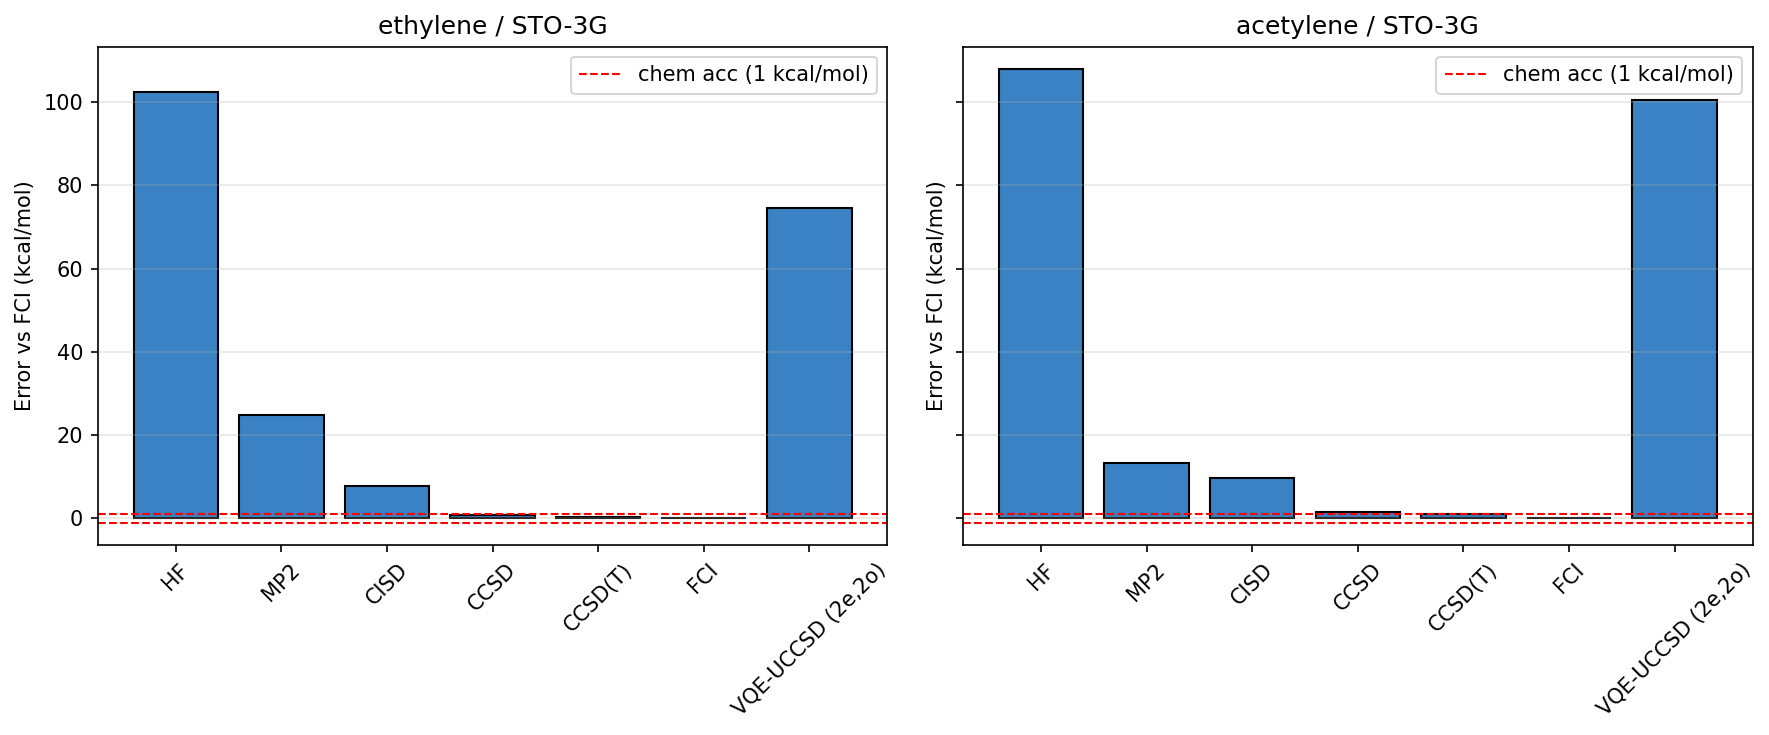

✅ Saved results/benchmark_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, sharey=True)
for ax, m in zip(axes, MOLECULES):
    sub = df[df["Molecule"] == m]
    methods = sub["Method"].tolist()
    errs = sub["Error (kcal/mol)"].tolist()
    bars = ax.bar(methods, errs, color="#3a82c4", edgecolor="black")
    ax.axhline(1.0, color="red", ls="--", lw=1, label="chem acc (1 kcal/mol)")
    ax.axhline(-1.0, color="red", ls="--", lw=1)
    ax.set_title(f"{m} / STO-3G")
    ax.set_ylabel("Error vs FCI (kcal/mol)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("results/benchmark_comparison.png", dpi=150)
plt.show()
print("✅ Saved results/benchmark_comparison.png")


## Step 6 — Chemical accuracy assertion for VQE

In [9]:
for m in MOLECULES:
    e_v = vqe_results[m]["vqe_energy"]
    e_fci_as = vqe_results[m]["fci_as"]
    err_mha = abs(e_v - e_fci_as) * 1000.0
    print(f"{m}: |E_VQE - E_FCI(AS)| = {err_mha:.6f} mHa")
    assert err_mha <= CHEM_ACCURACY_mHa, f"{m} VQE failed chemical accuracy"
print("✅ All VQE energies within 1.5936 mHa of active-space FCI")


ethylene: |E_VQE - E_FCI(AS)| = 0.000000 mHa
acetylene: |E_VQE - E_FCI(AS)| = 0.000000 mHa
✅ All VQE energies within 1.5936 mHa of active-space FCI
